<a href="https://colab.research.google.com/github/maryamhasnaasyamila/machine-learning/blob/praktikum/praktikum/praktikum13/notebooks/praktikum13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Praktikum 13: Neural Network**
*   **Nama:** Maryam Hasnaa' Syamila
*   **NIM:** 0110222067



#### **1. Import Library**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

#### **2. Load Dataset**

In [3]:
# sinkronisasi dengan google drive
from google.colab import drive
drive.mount('/content/drive')

# path dataset di Google Drive
file_path = "/content/drive/My Drive/SEMESTER 7/Machine Learning/praktikum13/datasets/titanic_data.csv"

# membaca dataset
df = pd.read_csv(file_path)

# menampilkan 5 baris pertama
df.head()

Mounted at /content/drive


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### **3. Cek Missing Value**

In [4]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


#### **4. Data Cleaning - Hapus kolom yang tidak digunakan**

In [5]:
# drop kolom
df = df.drop(columns=['Cabin', 'Name', 'Ticket'], axis=1)

#### **5. Visualisasi Distribusi dan Outlier pada Kolom Age**

<Axes: >

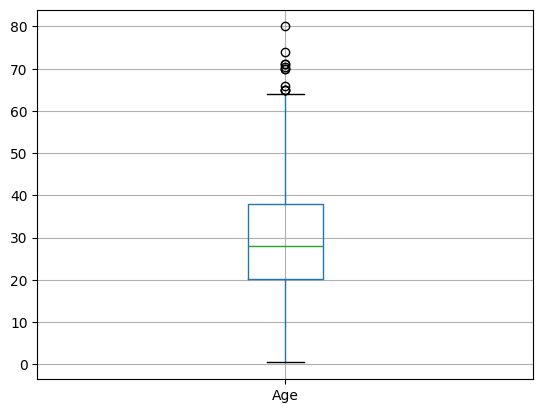

In [6]:
df.boxplot(column='Age')

#### **6. Mengisi Nilai Kosong pada Kolom Age dengan Median**

In [7]:
df['Age'].fillna(df['Age'].median(), inplace=True)

/tmp/ipython-input-1933487976.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


#### **7. Mengisi Nilai Kosong pada Kolom Embarked dengan Modus**

In [8]:
# replacing the missing value in "Embarked" column with mode values
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

/tmp/ipython-input-745450410.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


#### **8. Verifikasi Ulang Missing Values**

In [9]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


#### **9. Encoding Data Kategorikal**

In [11]:
replacements = {
    'Sex': {'male': 0, 'female': 1},
    'Embarked': {'S': 0, 'C': 1, 'Q': 2}
}
df.replace(replacements, inplace=True)

/tmp/ipython-input-2704438697.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(replacements, inplace=True)


#### **10. Cetak Dataset Hasil Encoding**

In [12]:
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,0,22.0,1,0,7.2500,0
1,2,1,1,1,38.0,1,0,71.2833,1
2,3,1,3,1,26.0,0,0,7.9250,0
3,4,1,1,1,35.0,1,0,53.1000,0
4,5,0,3,0,35.0,0,0,8.0500,0


#### **11. Split Data dan Transformasi (Scalling)**

In [13]:
# split data variabel X dan y
X = df.drop(columns=['Survived'])
y = df['Survived']

In [14]:
# transform data
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
# train-test split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

#### **12. Modelling - Struktur Input untuk Neural Network**

In [16]:
X_train.shape

(712, 8)

In [17]:
X_train.shape[1]

8

#### **13. Pembuatan Model Neural Network (Aristektur ANN)**

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

model = Sequential()

# hidden layer 1
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))

# dropout untuk mengurangi overfitting
model.add(Dropout(0.3))

# hidden layer 2
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.3))

# output layer (binary classification)
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### **14. Kompilasi Model dan Ringkasan Arsitektur (Model Summary)**

In [19]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

#### **15. Early Stopping (Pencegahan Overfitting selama Training)**

In [21]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

#### **16. Training Model Neural Network**

In [22]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6028 - loss: 0.8674 - val_accuracy: 0.6364 - val_loss: 0.7131
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6156 - loss: 0.7190 - val_accuracy: 0.6853 - val_loss: 0.6519
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6543 - loss: 0.6952 - val_accuracy: 0.6993 - val_loss: 0.6097
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6543 - loss: 0.6657 - val_accuracy: 0.7483 - val_loss: 0.5742
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6768 - loss: 0.5862 - val_accuracy: 0.7413 - val_loss: 0.5456
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6910 - loss: 0.6278 - val_accuracy: 0.7483 - val_loss: 0.5228
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7494 - loss: 0.5670 - val_accuracy: 0.7622 - val_loss: 0.4999
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7115 - loss: 0.5844 - val_accuracy: 0.7832 - 

#### **17. Evaluasi Model (Testing Data)**

In [23]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8263 - loss: 0.3969 
Test Loss: 0.41396045684814453
Test Accuracy: 0.8156424760818481


#### *18. *Visualisasi Hasil Pelatihan (Accuracy dan Loss)**

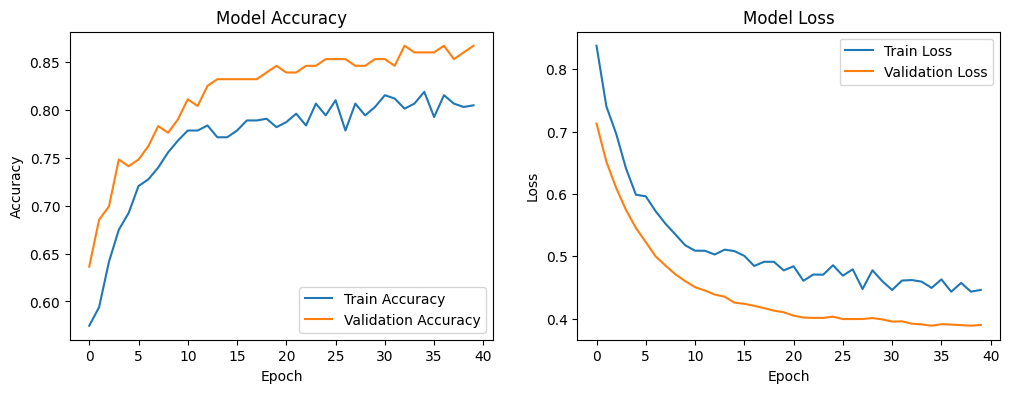

In [24]:
plt.figure(figsize=(12,4))

# accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

#### **Kesimpulan Akhir**
1. **Model Artificial Neural Network (ANN)** berhasil dibangun menggunakan arsitektur berurutan
(Sequential Model) dengan dua hidden layer berukuran 32 dan 16 neuron serta fungsi aktivasi **ReLU**, dan satu output layer dengan fungsi aktivasi **Sigmoid** untuk klasifikasi biner.
2. Model dikompilasi dengan **optimizer Adam dan loss function Binary Crossentropy**, serta dievaluasi menggunakan akurasi (accuracy) sebagai metrik utama.
3. Untuk mencegah overfitting, digunakan teknik **EarlyStopping** dengan parameter **monitor='val_loss', patience=5, dan restore_best_weights=True**, sehingga proses training berhenti otomatis ketika performa model tidak membaik lagi.
4. Berdasarkan hasil evaluasi:
o **Nilai Test Accuracy ≈ 0.80 (80%)**, menunjukkan model mampu memprediksi status
keselamatan penumpang dengan cukup baik.
o **Nilai Test Loss ≈ 0.39**, menunjukkan tingkat kesalahan prediksi yang rendah.
o Grafik accuracy dan loss menunjukkan tren **stabil tanpa tanda overfitting**, dengan
validation accuracy mendekati training accuracy.